In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as scp
# from scipy.cluster.hierarchy import linkage, dendrogram
import statsmodels.api as sm
import statsmodels.stats.multitest as multi
from matplotlib.pyplot import FormatStrFormatter
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
# Toggle as needed
# import warnings
# warnings.filterwarnings("ignore")
# import sys
# parent_path = '/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline'
# sys.path.append(parent_path)
# from SynOmics.processing.postprocessing import post_masking

In [4]:
# Colorblind-safe (Okabe-Ito) suggestion for manuscript-level plots
PAL_ASSOC = {
    "Infiltrated": "#0072B2",      # blue
    "Desert/Excluded": "#D55E00",    # vermillion
}

DATASET_COLORS = {
    "Origin": "#4d4d4d",
    "Avatars K5": "#66c2a5",
    "Avatars K10": "#fc8d62",
    "CTGAN": "#8da0cb",
    "Gaussian Copula": "#e78ac3",
    "Synthpop": "#a6d854",
    "TVAE": "#ffd92f",
}

In [55]:
def build_signed_log10q_long_df(
    results_by_dataset: dict,
    features_order=None,
    dataset_order=None,
) -> pd.DataFrame:
    """
    Build a long-format DataFrame containing signed -log10(p-value) per feature and dataset.

    Args:
        results_by_dataset (dict): Mapping dataset name -> logistic regression result DataFrame
            indexed by Feature and containing columns ['p_value', 'coeff'].
        features_order (list | None): Optional ordering of features for plotting.
        dataset_order (list | None): Optional ordering of datasets for plotting.

    Returns:
        pd.DataFrame: Long-format table with columns:
            ['Dataset', 'Feature', 'p_value', 'coeff', 'SignedLog10P', 'PalAssoc'].

    Raises:
        ValueError: If required columns are missing in any dataset DataFrame.
    """
    required_cols = {"Q_values", "Diff_Mean"}

    rows = []
    for dataset_name, df in results_by_dataset.items():
        if not required_cols.issubset(set(df.columns)):
            missing = required_cols - set(df.columns)
            raise ValueError(
                f"Dataset '{dataset_name}' is missing required columns: {missing}"
            )

        tmp = df.copy()
        tmp = tmp.reset_index().rename(columns={"index": "Feature"})
        tmp["Dataset"] = dataset_name

        tmp["SignedLog10Q"] = -np.log10(tmp["Q_values"].astype(float)) * np.sign(
            tmp["Diff_Mean"].astype(float)
        )
        tmp["PalAssoc"] = np.where(tmp["Diff_Mean"] >= 0, "Infiltrated", "Desert/Excluded")

        rows.append(
            tmp[["Dataset", "Cell Type", "Q_values", "Diff_Mean", "SignedLog10Q", "PalAssoc"]]
        )

    out = pd.concat(rows, ignore_index=True)

    if dataset_order is not None:
        out["Dataset"] = pd.Categorical(
            out["Dataset"], categories=dataset_order, ordered=True
        )

    if features_order is not None:
        out["Cell Type"] = pd.Categorical(
            out["Cell Type"], categories=features_order, ordered=True
        )

    return out


def plot_signed_log10q_origin_vs_synthetic(
    long_df: pd.DataFrame,
    dataset_order: list,
    figsize: tuple = (18, 6),
    strip_height: float = 0.012,
    strip_y: float = 1.01,
    p_thresholds: tuple = (0.05, 0.25),
    sort_features_by: str = "origin",  # "origin" | "global_mean" | "per_dataset"
    origin_name: str = "Origin",
    share_x_axis: bool = True,
    symmetric_x_axis: bool = True,
    x_padding_ratio: float = 0.05,
    savepath=None,
) -> plt.Figure:
    """
    Plot signed -log10(p-value) comparison across Origin vs synthetic datasets with dataset color strips.

    Args:
        long_df (pd.DataFrame): Output from build_signed_log10p_long_df().
            Must contain ['Dataset', 'Feature', 'SignedLog10P', 'PalAssoc'].
        dataset_order (list): Datasets order to display as columns.
        figsize (tuple): Figure size.
        strip_height (float): Height of the colored strip under each dataset title (axes fraction).
        strip_y (float): Vertical position of the strip (axes fraction).
        p_thresholds (tuple): P-value thresholds to draw symmetric vertical lines at ±(-log10(p)).
        sort_features_by (str): Sorting strategy for y-axis feature order.
            - "origin": sort by SignedLog10P in the Origin dataset (recommended for comparison).
            - "global_mean": sort by mean SignedLog10P across all datasets.
            - "per_dataset": each subplot sorts features independently (NOT sharey-friendly).
        origin_name (str): Dataset name used when sort_features_by="origin".
        share_x_axis (bool): If True, enforce same x-limits for all subplots.
        symmetric_x_axis (bool): If True and share_x_axis=True, make x-limits symmetric around 0.
        x_padding_ratio (float): Padding ratio added to computed x-limits (e.g., 0.05 => +5%).
        savepath (str | None): If provided, path to save figure.

    Returns:
        matplotlib.figure.Figure: Matplotlib figure.

    Raises:
        ValueError: If required columns are missing or sorting option invalid.
    """
    required_cols = {"Dataset", "Cell Type", "SignedLog10Q", "PalAssoc"}
    if not required_cols.issubset(set(long_df.columns)):
        missing = required_cols - set(long_df.columns)
        raise ValueError(f"Input long_df is missing required columns: {missing}")

    plot_df = long_df.copy()
    plot_df["Dataset"] = pd.Categorical(
        plot_df["Dataset"], categories=dataset_order, ordered=True
    )

    # ---- Feature ordering (descending SignedLog10P) ----
    if sort_features_by == "origin":
        if origin_name not in plot_df["Dataset"].cat.categories:
            raise ValueError(
                f"origin_name='{origin_name}' not found in dataset_order/categories."
            )
        origin_df = plot_df[plot_df["Dataset"] == origin_name].copy()
        feat_order = (
            origin_df.dropna(subset=["SignedLog10Q"])
            .sort_values("SignedLog10Q", ascending=False)["Cell Type"]
            .astype(str)
            .tolist()
        )
        all_feats = plot_df["Cell Type"].astype(str).unique().tolist()
        missing = [f for f in all_feats if f not in feat_order]
        feat_order = feat_order + sorted(missing)

    elif sort_features_by == "global_mean":
        feat_order = (
            plot_df.groupby("Cell Type")["SignedLog10P"]
            .mean()
            .sort_values(ascending=False)
            .index.astype(str)
            .tolist()
        )

    elif sort_features_by == "per_dataset":
        feat_order = None
    else:
        raise ValueError(
            "sort_features_by must be one of: 'origin', 'global_mean', 'per_dataset'."
        )

    if feat_order is not None:
        plot_df["Cell Type"] = pd.Categorical(
            plot_df["Cell Type"].astype(str),
            categories=feat_order,
            ordered=True,
        )

    # ---- Global x-limits (shared across panels) ----
    x_min = float(plot_df["SignedLog10Q"].min(skipna=True))
    x_max = float(plot_df["SignedLog10Q"].max(skipna=True))

    if share_x_axis:
        if symmetric_x_axis:
            max_abs = max(abs(x_min), abs(x_max))
            max_abs = max_abs * (1.0 + x_padding_ratio)
            global_xlim = (-max_abs, max_abs)
        else:
            span = x_max - x_min
            pad = span * x_padding_ratio
            global_xlim = (x_min - pad, x_max + pad)
    else:
        global_xlim = None

    # Precompute threshold x positions
    thr_vals = {}
    for p in p_thresholds:
        if p <= 0 or p >= 1:
            raise ValueError(f"Invalid p-value threshold: {p}. Must be in (0, 1).")
        thr_vals[p] = -np.log10(p)

    ncols = len(dataset_order)
    fig, axes = plt.subplots(
        1,
        ncols,
        figsize=figsize,
        sharey=(sort_features_by != "per_dataset"),
        gridspec_kw={"wspace": 0.15},
    )
    if ncols == 1:
        axes = [axes]

    for col_idx, dataset in enumerate(dataset_order):
        ax = axes[col_idx]

        sub = plot_df[plot_df["Dataset"] == dataset].dropna(subset=["SignedLog10Q"]).copy()
        if sort_features_by == "per_dataset":
            sub = sub.sort_values("SignedLog10Q", ascending=False)

        sns.barplot(
            ax=ax,
            data=sub,
            y="Cell Type",
            x="SignedLog10Q",
            hue="PalAssoc",
            dodge=False,
            palette=PAL_ASSOC,
            hue_order=["Infiltrated", "Desert/Excluded"],
            orient="h",
            order=None if sort_features_by == "per_dataset" else feat_order,
        )

        # Apply shared x-axis limits
        if global_xlim is not None:
            ax.set_xlim(*global_xlim)

        # Center line (0)
        ax.axvline(0, color="black", linewidth=1)

        # Threshold lines (symmetric)
        if 0.05 in thr_vals:
            x = thr_vals[0.05]
            ax.axvline(x=+x, linewidth=1, linestyle="-", c="red")
            ax.axvline(x=-x, linewidth=1, linestyle="-", c="red")
        if 0.25 in thr_vals:
            x = thr_vals[0.25]
            ax.axvline(x=+x, linewidth=1, linestyle="--", c="purple")
            ax.axvline(x=-x, linewidth=1, linestyle="--", c="purple")

        ax.set_title(dataset, fontsize=12, fontweight="bold", pad=16)
        ax.set_xlabel(r"Signed $\log_{10}(q\mathrm{-value})$", fontsize=11)
        ax.set_ylabel("" if col_idx > 0 else "")

        # Dataset colored strip
        dataset_color = DATASET_COLORS.get(dataset, "#cccccc")
        ax.add_patch(
            Rectangle(
                (0, strip_y),
                1,
                strip_height,
                transform=ax.transAxes,
                facecolor=dataset_color,
                edgecolor="none",
                clip_on=False,
                zorder=10,
            )
        )

        leg = ax.get_legend()
        if leg is not None:
            leg.remove()

        ax.tick_params(axis="y", labelsize=10)
        ax.tick_params(axis="x", labelsize=10)

    # Global legend
    handles = [Rectangle((0, 0), 1, 1, fc=PAL_ASSOC[k]) for k in ["Infiltrated", "Desert/Excluded"]]
    fig.legend(
        handles=handles,
        labels=["Infiltrated", "Desert/Excluded"],
        loc="center left",
        bbox_to_anchor=(0.92, 0.5),
        title="Association",
        frameon=True,
        fontsize=11,
        title_fontsize=12,
    )

    plt.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight", facecolor="white")

    return fig

/tmp/ipykernel_1938683/757656405.py:261: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


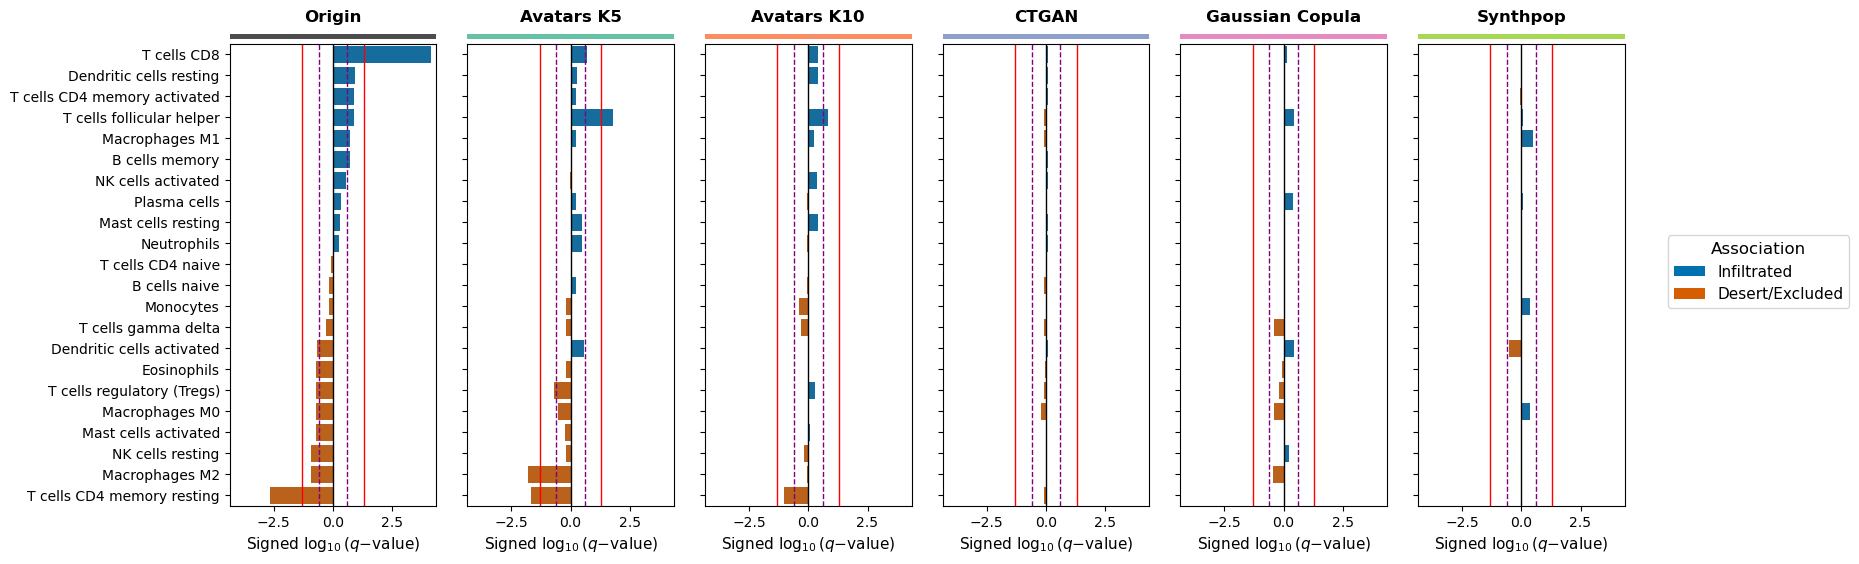

In [16]:
results_dict = {}
seed = 3
datasets = [f'avatarsk5_{seed}', f'avatarsk10_{seed}', f'ctgan_{seed}', f'gaussiancopula_{seed}', f'synthpop_{seed}']
names = ['Avatars K5', 'Avatars K10', 'CTGAN', 'Gaussian Copula', 'Synthpop']
cb_res_or = pd.read_csv('../ccRCC/NarrowUtility/CellDecovo/ResultsDA_cibersortx/Origin.csv')
results_dict['Origin']=cb_res_or
for i, dataset in enumerate(datasets):
    cb_res = pd.read_csv(f'../ccRCC/NarrowUtility/CellDecovo/ResultsDA_cibersortx/Seed_{seed}/{dataset}.csv')
    results_dict[names[i]] = cb_res

    
dataset_order = ["Origin", "Avatars K5", 'Avatars K10','CTGAN',"Gaussian Copula", "Synthpop"]

long_df_q = build_signed_log10q_long_df(
    results_by_dataset=results_dict,
    dataset_order=dataset_order,
)

fig_q = plot_signed_log10q_origin_vs_synthetic(
    long_df=long_df_q,
    dataset_order=dataset_order,
    figsize=(18, 6),
    sort_features_by = 'origin',
    savepath=None
)

fig_q.savefig(
    f"ccRCC_cibersortx/Seed_{seed}.pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

In [1]:
from typing import Dict, Tuple, List, Optional, Callable
import warnings
import math

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Consistent color definitions used across SynOmics visualizations
DATA_COLORS = {"real": "#4c72b0", "synthetic": "#dd8452"}
PVAL_BIN_COLORS_DEFAULT = ["#d62728", "#ff7f0e", "#1f77b4", "#cccccc"]  # red, orange, blue, gray


def _normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Strip whitespace from dataframe column names.

    Args:
        df (pd.DataFrame): Input dataframe.

    Returns:
        pd.DataFrame: Dataframe with stripped columns.
    """
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    return df


def _resolve_column(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    """
    Resolve a column name from a list of candidate aliases.

    Args:
        df (pd.DataFrame): Input dataframe.
        candidates (List[str]): Candidate column names in priority order.

    Returns:
        Optional[str]: Matched column name if found.
    """
    cols = set(df.columns)
    for c in candidates:
        if c in cols:
            return c
    return None


def plot_pathway(
    ssGSEA_comparison: Dict[str, pd.DataFrame],
    ref_pathway_list: List[str],
    highlight_pathways: Optional[List[str]] = None,
    origin_name: str = "Origin",
    term_col: str = "Term",
    pval_col: str = "adj_pvalues",
    diff_col: str = "Diff_NES",
    # shorten_terms: bool = True,
    term_formatter: Optional[Callable[[str], str]] = None,
    pval_bin_colors: List[str] = PVAL_BIN_COLORS_DEFAULT,
    dataset_colors: Optional[Dict[str, str]] = None,
    figsize: Optional[Tuple[float, float]] = None,
    fig_width_min: float = 14.0,
    bubble_size: float = 170.0,
    title_pad: float = 14.0,
    dataset_strip_y: float = 1.01,
    dataset_strip_lw: float = 4.0,
    dataset_strip_pad: float = 0.0,
    show: bool = True,
    save_path: Optional[str] = None,
    return_dataframe: bool = True,
    allow_column_aliases: bool = True,
    # New options:
    order_by: str = "pvalue",  # "pvalue" (default) or "diff"
    order_ascending: bool = True,  # when ordering by diff, ascending if True
    negative_shade: bool = True,
    negative_shade_color: str = "#e6f2ff",
    negative_shade_alpha: float = 0.12,
) -> Tuple[plt.Figure, Optional[pd.DataFrame]]:
    """
    Plot a pathway bubble scatter plot from ssGSEA comparison results (Term, Diff_NES, adjusted p-value).

    New options:
        order_by: "pvalue" (default) or "diff" to order y-axis terms using diff_col in origin dataset.
        order_ascending: when order_by="diff", sort ascending if True (most negative first).
        negative_shade: if True, shade the negative side (x < 0) for easier reading.

    Layout:
        - Default grid: 3 columns x 2 rows (can expand rows if number of datasets > 6)
        - Show y-axis labels on the leftmost column of the grid (both rows if 2 rows).
    """
    if not ssGSEA_comparison:
        raise ValueError("ssGSEA_comparison must not be empty.")
    if not ref_pathway_list:
        raise ValueError("ref_pathway_list must not be empty.")
    if highlight_pathways is None:
        highlight_pathways = []
    # normalize any whitespace in provided column-name arguments so aliases match sanitized df columns
    if isinstance(term_col, str):
        term_col = term_col.strip()
    if isinstance(pval_col, str):
        pval_col = pval_col.strip()
    if isinstance(diff_col, str):
        diff_col = diff_col.strip()

    datasets = list(ssGSEA_comparison.keys())
    all_data_to_plot: List[pd.DataFrame] = []
    found_any = False

    term_candidates = [term_col, "term", "Pathway", "pathway"]
    pval_candidates = [pval_col, "adj_pvalue", "adj.P.Val", "padj", "qvalue", "q-value", "FDR", "FDR q-val"]
    diff_candidates = [diff_col, "Diff_NES", "diff_nes", "NES_diff", "delta_NES", "NES", "nes", 'Diff_Mean']

    for ds_name in datasets:
        df_ds = ssGSEA_comparison.get(ds_name)
        if df_ds is None or not isinstance(df_ds, pd.DataFrame):
            warnings.warn(f"Skipping {ds_name}: not a pandas DataFrame.")
            continue

        df_ds = _normalize_columns(df_ds)

        if allow_column_aliases:
            term_resolved = _resolve_column(df_ds, term_candidates)
            pval_resolved = _resolve_column(df_ds, pval_candidates)
            diff_resolved = _resolve_column(df_ds, diff_candidates)
        else:
            term_resolved = term_col if term_col in df_ds.columns else None
            pval_resolved = pval_col if pval_col in df_ds.columns else None
            diff_resolved = diff_col if diff_col in df_ds.columns else None

        missing = []
        if term_resolved is None:
            missing.append(term_col)
        if pval_resolved is None:
            missing.append(pval_col)
        if diff_resolved is None:
            missing.append(diff_col)

        if missing:
            warnings.warn(
                f"Skipping {ds_name}: missing required columns: {missing}. "
                f"Available columns: {list(df_ds.columns)}"
            )
            continue

        sub_df = df_ds[df_ds[term_resolved].isin(ref_pathway_list)].copy()
        if sub_df.empty:
            warnings.warn(f"Skipping {ds_name}: none of ref_pathway_list terms were found.")
            continue

        found_any = True

        # rename resolved columns into canonical names or into diff_col name for flexibility
        sub_df = sub_df.rename(
            columns={
                term_resolved: "Term",
                pval_resolved: "adj_pvalues",
                diff_resolved: diff_col,
            }
        )
        sub_df["Dataset"] = ds_name

        sub_df["adj_pvalues"] = pd.to_numeric(sub_df["adj_pvalues"], errors="coerce")
        sub_df[diff_col] = pd.to_numeric(sub_df[diff_col], errors="coerce").fillna(0.0)

        sub_df["-log10(qvalue)"] = -np.log10(sub_df["adj_pvalues"].clip(lower=np.nextafter(0, 1)))

        all_data_to_plot.append(sub_df[["Dataset", "Term", "adj_pvalues", diff_col, "-log10(qvalue)"]])

    if not found_any:
        raise ValueError("No dataset contained required columns and at least one requested pathway.")

    df_plot = pd.concat(all_data_to_plot, ignore_index=True)

    present = set(df_plot["Term"].unique())
    y_terms = [p for p in ref_pathway_list if p in present]
    if not y_terms:
        raise ValueError("None of the pathways in ref_pathway_list were found after filtering.")

    # If origin dataset exists, reorder pathways based on user's order_by choice
    origin_df = df_plot[df_plot["Dataset"] == origin_name].copy()
    if not origin_df.empty:
        if order_by == "diff":
            # sort by provided diff_col (Diff_Mean etc.)
            origin_df = origin_df.sort_values(by=diff_col, ascending=order_ascending, na_position="last")
        else:
            # default: sort by adjusted p-value ascending (smallest p first)
            origin_df = origin_df.sort_values(by="adj_pvalues", ascending=True, na_position="last")

        origin_sorted = origin_df["Term"].tolist()
        # keep ref_pathway_list coverage + order stability
        merged = []
        for t in origin_sorted + list(ref_pathway_list):
            if (t in ref_pathway_list) and (t in present) and (t not in merged):
                merged.append(t)
        y_terms = merged

    # Display labels (shortened)
    if term_formatter is not None:
        y_labels = [term_formatter(t) for t in y_terms]
    else:
        y_labels = list(y_terms)

    mapping = {term: idx for idx, term in enumerate(y_terms)}
    y_pos = np.arange(len(y_terms))

    max_abs_nes = np.nanmax(np.abs(df_plot[diff_col].to_numpy(dtype=float)))
    if not np.isfinite(max_abs_nes) or max_abs_nes == 0:
        max_abs_nes = 1.0

    bins = [0, 0.01, 0.05, 0.25, 1.01]
    bin_labels = ["p<0.01", "0.01≤p<0.05", "0.05≤p<0.25", "p≥0.25"]
    color_map = dict(zip(bin_labels, pval_bin_colors))

    df_plot["pvalue_bin"] = pd.cut(
        df_plot["adj_pvalues"],
        bins=bins,
        labels=bin_labels,
        include_lowest=True,
        right=False,
    )

    # Layout: fixed 3 columns; default 2 rows (3x2). Expand rows if more datasets.
    n_datasets = len(datasets)
    ncols = 3
    nrows = 2
    if n_datasets > ncols * nrows:
        # expand rows to fit datasets (but keep 3 columns)
        nrows = math.ceil(n_datasets / ncols)
        warnings.warn(f"Number of datasets ({n_datasets}) > 6, expanding to {nrows} rows x {ncols} cols.")

    if figsize is None:
        fig_width = max(3.5 * ncols + 2, fig_width_min)
        fig_height = max(0.6 * len(y_terms) + 3, 7) if nrows <= 2 else max(0.6 * len(y_terms) + 3, 7) * (nrows / 2)
        figsize = (fig_width, fig_height)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharey=True, sharex=True)
    axes_list = list(np.array(axes).flatten())

    plt.subplots_adjust(left=0.28, right=0.88, top=0.92, bottom=0.06, hspace=0.28, wspace=0.18)

    highlight_set = set(highlight_pathways or [])

    for i, ds in enumerate(datasets):
        if i >= len(axes_list):
            warnings.warn(f"Not enough subplot axes for dataset '{ds}'; skipping.")
            continue
        ax = axes_list[i]
        sub = df_plot[df_plot["Dataset"] == ds].copy()
        sub["y"] = sub["Term"].map(mapping)

        if sub.empty:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=10, color="grey", transform=ax.transAxes)
            ax.set_xlim(-max_abs_nes * 1.05, max_abs_nes * 1.05)
            ax.set_title(ds, fontsize=10, fontweight="bold", pad=title_pad)
            ax.tick_params(left=False, labelleft=False)
        else:
            # shade negative side if requested
            if negative_shade:
                ax.axvspan(-max_abs_nes * 1.05, 0, color=negative_shade_color, alpha=negative_shade_alpha, zorder=0)

            bubble_colors = sub["pvalue_bin"].map(color_map).fillna("#cccccc")

            # Priority drawing:
            # draw non-significant (adj_pvalues >= 0.25) first, then significant (adj_pvalues < 0.25)
            sig_mask = sub["adj_pvalues"] < 0.25
            non_sig = sub[~sig_mask]
            sig = sub[sig_mask]

            # draw non-significant first (lower zorder)
            if not non_sig.empty:
                ax.scatter(
                    x=non_sig[diff_col],
                    y=non_sig["y"],
                    s=bubble_size,
                    c=non_sig["pvalue_bin"].map(color_map).fillna("#cccccc"),
                    edgecolor="k",
                    linewidths=0.4,
                    alpha=0.95,
                    zorder=2,
                )
            # then draw significant on top (higher zorder)
            if not sig.empty:
                ax.scatter(
                    x=sig[diff_col],
                    y=sig["y"],
                    s=bubble_size,
                    c=sig["pvalue_bin"].map(color_map).fillna("#cccccc"),
                    edgecolor="k",
                    linewidths=0.8,
                    alpha=0.98,
                    zorder=3,
                )

            ax.axvline(x=0, color="gray", linestyle="--", linewidth=1.2, zorder=1)
            ax.set_xlim(-max_abs_nes * 1.05, max_abs_nes * 1.05)
            ax.set_xlabel(diff_col, fontsize=9, labelpad=6)

            ax.set_yticks(y_pos)
            ax.set_ylim(-0.5, len(y_terms) - 0.5)
            ax.invert_yaxis()
            ax.set_title(ds, fontsize=10, fontweight="bold", pad=title_pad)
            ax.grid(axis="y", linestyle="--", alpha=0.4)

            # Determine grid column for this axis so left-column axes show y labels
            col_idx = i % ncols
            if col_idx == 0:
                # leftmost column: show y tick labels
                ax.set_yticklabels(y_labels, fontsize=9)
                ax.tick_params(axis="y", which="major", pad=6, left=True, labelleft=True)
                for j, label in enumerate(ax.get_yticklabels()):
                    term = y_terms[j]
                    if term in highlight_set:
                        label.set_color(DATA_COLORS["real"])
                        label.set_fontweight("bold")
                    else:
                        label.set_color("black")
            else:
                # other columns: hide y tick labels
                ax.tick_params(left=False, labelleft=False)

        # dataset color strip
        if dataset_colors is not None:
            strip_color = dataset_colors.get(ds, "#333333")
            y_strip = dataset_strip_y + dataset_strip_pad
            ax.plot(
                [0.08, 0.92],
                [y_strip, y_strip],
                transform=ax.transAxes,
                color=strip_color,
                lw=dataset_strip_lw,
                clip_on=False,
                solid_capstyle="round",
            )

    # Hide any unused axes if fewer datasets than grid cells
    for j in range(len(datasets), len(axes_list)):
        ax_unused = axes_list[j]
        ax_unused.set_visible(False)

    # import matplotlib.patches as mpatches

    # legend_patches = [mpatches.Patch(color=color_map[l], label=l) for l in bin_labels]
    # # place legend on the last visible axis
    # last_ax_idx = max(0, min(len(datasets) - 1, len(axes_list) - 1))
    # axes_list[last_ax_idx].legend(
    #     handles=legend_patches,
    #     title=pval_col,
    #     bbox_to_anchor=(1.05, 1),
    #     loc="upper left",
    #     fontsize=8,
    #     title_fontsize=9,
    #     frameon=False,
    # )

    plt.tight_layout(rect=[0, 0.03, 0.88, 0.98])

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    if show:
        plt.show()

    df_plot["y"] = df_plot["Term"].map(mapping)
    df_plot = df_plot[["Dataset", "Term", "adj_pvalues", diff_col, "-log10(qvalue)", "y", "pvalue_bin"]]

    return (fig, df_plot) if return_dataframe else (fig, None)

In [2]:
seeds = [0,1, 2, 3, 42]  # seeds/replicates to include
method_bases = {
    'Avatars K5': 'avatarsk5',
    'Avatars K10': 'avatarsk10',
    'CTGAN': 'ctgan',
    'Gaussian Copula': 'gaussiancopula',
    'Synthpop': 'synthpop',
}

results_dict = {}
# load Origin
origin_path = '../ccRCC/NarrowUtility/CellDecovo/ResultsDA_cibersortx/Origin.csv'
cb_res_or = pd.read_csv(origin_path)
cb_res_or.columns = cb_res_or.columns.str.strip()
# ensure the Term column name is consistent; change below if your column has different name
term_col_name = 'Cell Type'
if term_col_name in cb_res_or.columns:
    cb_res_or[term_col_name] = cb_res_or[term_col_name].astype(str).str.strip()
results_dict['Origin'] = cb_res_or

# combine replicates for each method
for name, base in method_bases.items():
    dfs = []
    for s in seeds:
        fpath = f'../ccRCC/NarrowUtility/CellDecovo/ResultsDA_cibersortx/Seed_{s}/{base}_{s}.csv'
        try:
            df = pd.read_csv(fpath)
        except Exception as e:
            warnings.warn(f"Could not read {fpath}: {e}")
            continue
        df = _normalize_columns(df)
        # strip term values if present
        if term_col_name in df.columns:
            df[term_col_name] = df[term_col_name].astype(str).str.strip()
        df['Seed'] = s
        dfs.append(df)
    if not dfs:
        warnings.warn(f"No files found for method {name}; skipping.")
        continue
    combined = pd.concat(dfs, ignore_index=True)
    results_dict[name] = combined

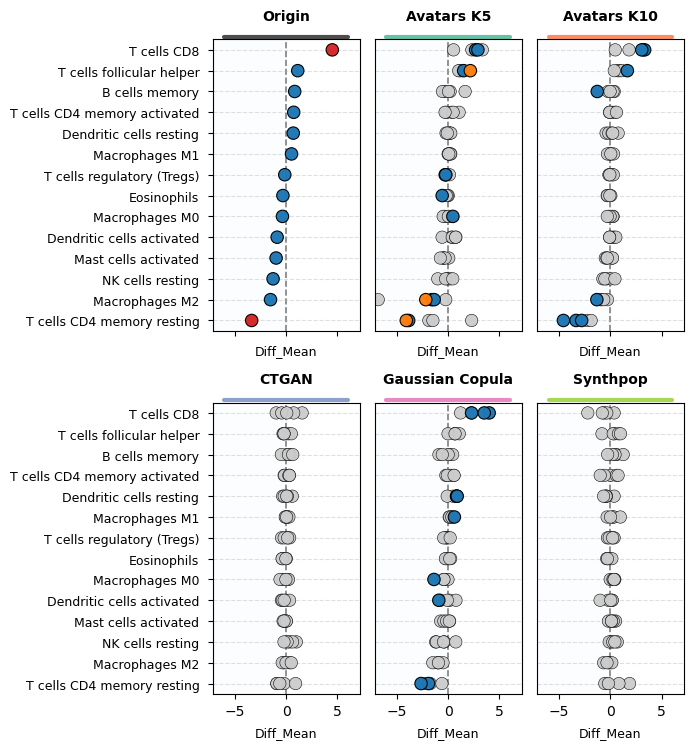

In [5]:
DATASET_COLORS = {
    "Origin": "#4d4d4d",
    "Avatars K5": "#66c2a5",
    "Avatars K10": "#fc8d62",
    "CTGAN": "#8da0cb",
    "Gaussian Copula": "#e78ac3",
    "Synthpop": "#a6d854",
    "TVAE": "#ffd92f",
}

ref_pathway_list = results_dict['Origin'].sort_values(by="Q_values")['Cell Type'].values[0:14].tolist()
fig, df_used = plot_pathway(
    ssGSEA_comparison=results_dict,
    ref_pathway_list=ref_pathway_list,
    highlight_pathways=None,
    origin_name="Origin",
    term_col="Cell Type",
    pval_col="Q_values",
    diff_col="Diff_Mean",
    figsize=(8, 8),
    dataset_colors=DATASET_COLORS,
    bubble_size = 80,
    dataset_strip_lw=3.0,
    dataset_strip_y=1.01,
    dataset_strip_pad=0.0,
    show=True,
    save_path=None,
    order_by = "diff",  # "pvalue" (default) or "diff"
    order_ascending = False,
)

# If you want to save the figure:
fig.savefig('ccRCC_cibersortx/BubblePlot_all_seed.pdf', dpi=300, bbox_inches="tight", facecolor="white")
plt.show()